In [ ]:
# Hypothesis Set-up Doc

In [1]:
# ── Core data stack ──────────────────────────
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(janitor))
suppressPackageStartupMessages(library(arrow))
suppressPackageStartupMessages(library(DBI))
suppressPackageStartupMessages(library(duckdb))
suppressPackageStartupMessages(library(duckplyr))

# ── Modelling ────────────────────────────────
suppressPackageStartupMessages(library(lme4))
suppressPackageStartupMessages(library(lmerTest))
suppressPackageStartupMessages(library(broom))
suppressPackageStartupMessages(library(performance))
suppressPackageStartupMessages(library(see))

# ── Sensitivity ──────────────────────────────
suppressPackageStartupMessages(library(sensitivity))
suppressPackageStartupMessages(library(ranger))

# ── Visualisation ────────────────────────────
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(plotly))
suppressPackageStartupMessages(library(ComplexUpset))

# core optimization
options(ranger.num.threads = 4)
duckplyr::db_exec("PRAGMA threads=4;")

duckdb keeps downloaded extensions and secrets in a temporary directory:
ℹ /tmp/RtmpS2jBxM/duckdb
This is removed when the R session ends.
• Extensions are re-downloaded each session.
• Secrets are lost.
ℹ Run duckdb(shared_home = TRUE) (or create ~/.duckdb) to keep them (suitable for most users).
ℹ Run duckdb(shared_home = FALSE) to accept the temporary directory (and silence this message).
ℹ See ?duckdb_storage for details and alternatives.


In [2]:
# Sourcing Helpers and Files
source("./functions.R")
source("./data_processing.R")
source("./plots.R")

In [ ]:
# Compilation of LHS, GA and Validation
##### -------
# IN THIS VERSION OF CONFIG ALL DEBATES ARE CONSIDERED FOR LSH AND GA (EXCLUDING CONTROLS)
# THE DATA FOR LHS AND GA ARE CALIBRATED ON 43 DEBATES AND VALIDATED ON 12 HELD-OUT DEBATES
##### -------
source("./framework_analysis.R")
df_empirical <- empirical_prep("./data/data_complete_anonymised.csv")
result_lhs_train <- process_run(lhs)
#result_ga_train <- process_run(ga)
#result_ga_val <- process_run(val)

# LHS
lhs_bundle <- list(
  sim_inputs = result_lhs_train,
  df_empirical = df_empirical
)

lhs_outputs <- analyze_processed_run(lhs_bundle)

# GA & VAL
# ga_bundle <- list(
#   sim_inputs = result_ga_train,
#   sim_val    = result_ga_val,
#   df_empirical = df_empirical
# )

# ga_outputs <- analyze_processed_run(ga_bundle)

duckdb keeps downloaded extensions and secrets in a temporary directory:
ℹ /tmp/RtmpS2jBxM/duckdb
This is removed when the R session ends.
• Extensions are re-downloaded each session.
• Secrets are lost.
ℹ Run duckdb(shared_home = TRUE) (or create ~/.duckdb) to keep them (suitable for most users).
ℹ Run duckdb(shared_home = FALSE) to accept the temporary directory (and silence this message).
ℹ See ?duckdb_storage for details and alternatives.
lazy data frame collected and pulled into R memory, starting col coercion and NA diagnostics

no missing required columns, proceeding with mutations



[13:58:48] Char and Logical Col coercion finished, starting NA diagnostics...
             model_type       current_condition      selected_debate_id 
                      0                       0                       0 
           debate_label   current_experiment_id              max_cycles 
                      0                       0                       0 
              converged     use_distinct_agents           speaking_mode 
                      0                       0                       0 
      logged_batch_seed               pro_count              anti_count 
                      0                       0                       0 
       convergence_rate    confidence_threshold     repulsion_threshold 
                      0                       0                       0 
     repulsion_strength     convergence_rate_sd confidence_threshold_sd 
                      0                       0                       0 
 repulsion_threshold_sd   repulsion_strength_s

No NA values in rows or columns

No violations found, good on ya ;-+



[13:59:11] Skipping agent loading - sensitivity scope
[13:59:11] Skipping directional dfs, sensitivity scope
piece rows: 34400 
key: bipolarization_FALSE_nospeak | lookup: bipolarization_FALSE | in param_cols_by_model: TRUE 
rf_data rows for bipolarization_FALSE_nospeak mae : 34400 
rf_data rows for bipolarization_FALSE_nospeak opinion_variance : 34400 
rf_data rows for bipolarization_FALSE_nospeak convergence_cycle : 34400 
piece rows: 172000 
  subsampled to: 50000 
key: bipolarization_FALSE_speak | lookup: bipolarization_FALSE | in param_cols_by_model: TRUE 
rf_data rows for bipolarization_FALSE_speak mae : 50000 
rf_data rows for bipolarization_FALSE_speak opinion_variance : 50000 
rf_data rows for bipolarization_FALSE_speak convergence_cycle : 50000 
piece rows: 344000 
  subsampled to: 50000 
key: bipolarization_TRUE_nospeak | lookup: bipolarization_TRUE | in param_cols_by_model: TRUE 
rf_data rows for bipolarization_TRUE_nospeak mae : 50000 
rf_data rows for bipolarization_TRUE_

DEBUG - complete cases count:

DEBUG - df_conv_debate speaking_mode table:




FALSE  TRUE  <NA> 
  172   129     0 
[1] 258


Notice: GAML GA bounds extraction started



In [ ]:
con <- dbConnect(duckdb())
pull_cols <- c("model_type", "current_condition", "selected_debate_id", "debate_label", "use_distinct_agents", "speaking_mode",
"agent_id", "convergence_cycle", "logged_batch_seed", "opinion", "final_attitude", "initial_opinion", "pro_reduction", "opinion_change")
df_test <- load_and_prepare("./data/ga_agent_level_results.parquet", config = run_configs$ga_main, col_names = ag_cols, pull_cols = pull_cols, con = con)
str(df_test)

In [8]:
is.null(ga_outputs$results$behavioral$stochastic)

[1] FALSE

In [ ]:
# TODO confirmed that objects are created, next step is modifying the duckdb call for upset, valence, directional 
# NEXT, decide on plots to include in RQ1, test and validate. // follow up is a fun rull from scratch (copy the parquet caches somewhere else) // once validated can start thinking about a refactor
# NEED to write abstract for conference (GAMA DAYS), 

# FRIDAY
# write abstract for GAMA Days / check duckdb calls for upset, valence, directional / revise plots for RQ1 and compile
# IF TIME, full run and think about structure for a refactor

# Sensitivity (which parameters matter and which don't)
## PCC/PRCC, PDP grid, amplitude table? (check)
lhs_outputs$results$sensitivity$combined$pcc
lhs_outputs$results$sensitivity$combined$prcc

# Convergence Dynamics (how the models behave mechanically)
## convergence_anal, conv_diff, clusters
ga_outputs$results$behavioral$convergence
ga_outputs$results$dynamics$conv_debate
ga_outputs$results$dynamics$clusters

# Calibration headroom (why the calibration has limited headroom)
## variance decomposition, RF Rsq per cell

# Cross-model failure patterns (which debates are hard for eveyrone to predict)
## upset plot (for each debate, which model types failed - worse than no change), stochasticity check(not very useful given little stochasticity in the model design)
ga_outputs$results$comparisons$upset_prep # TODO needs the upset branch to run in process_run (to finish after loading lhs once and checking whether a duckdb call is necessary)
ga_outputs$results$behavioral$stochastic


# Directional/valence (does the model systematically miss in one direction)
## valence_metrics 
ga_outputs$results$comparisons$valence_metrics



# Empirical Data & Context
The idea of this document is to provide a direct mapping of the hypotheses related to the SimBA project that have been developed and analysed as of 2/9/26.

For context this preface will highlight the differences in T(ime) values that will set the stage for the remaining analyses.
- T0: Participants enter the empirical study and fill out a questionnaire with their attitudes towards meat consumption reduction.
- T1: Participants are presented an information document related to meat consumption reduction and are encouraged to read it, they also fill out another questionnaire about attitudes.
- T2: Post-debate, participants are asked to fill out a questionnaire regarding their attitudes toward meat consumption reduction

# Simulation Context
The data presented after the empirical section consists of models of social influence adapted from Flache et al. (2017) to try and understand the empirical behavior of agents nested in debates that filled out questionnaires between T0-T2
- LHS and GA algorithms were used for calibration of the model parameters (with only one repeat for the moment)
- In both the LHS and GA runs heterogeneous and homogeneous debates were considered and are hereafter presented
- The calibration simulations were run with 43 debates (~80%) and then validated on 12 held-out debates (~20%)

In [27]:
# Empirical Data 1 (Stat check table)
emp <- ga_outputs$results$comparisons$empirical
emp

condition,mean_change_t0_t1,sd_change_t0_t1,mean_change_t1_t2,sd_change_t1_t2,mean_change_t0_t2,sd_change_t0_t2,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Control,0.04355442,0.1017697,0.02117375,0.05674247,0.06472816,0.1174125,187
Heterogeneous,0.04938052,0.1029154,0.01848564,0.04769456,0.06786616,0.1033794,176
Homogeneous,0.08334591,0.0977895,-0.01283213,0.06368935,0.07051379,0.1021346,92


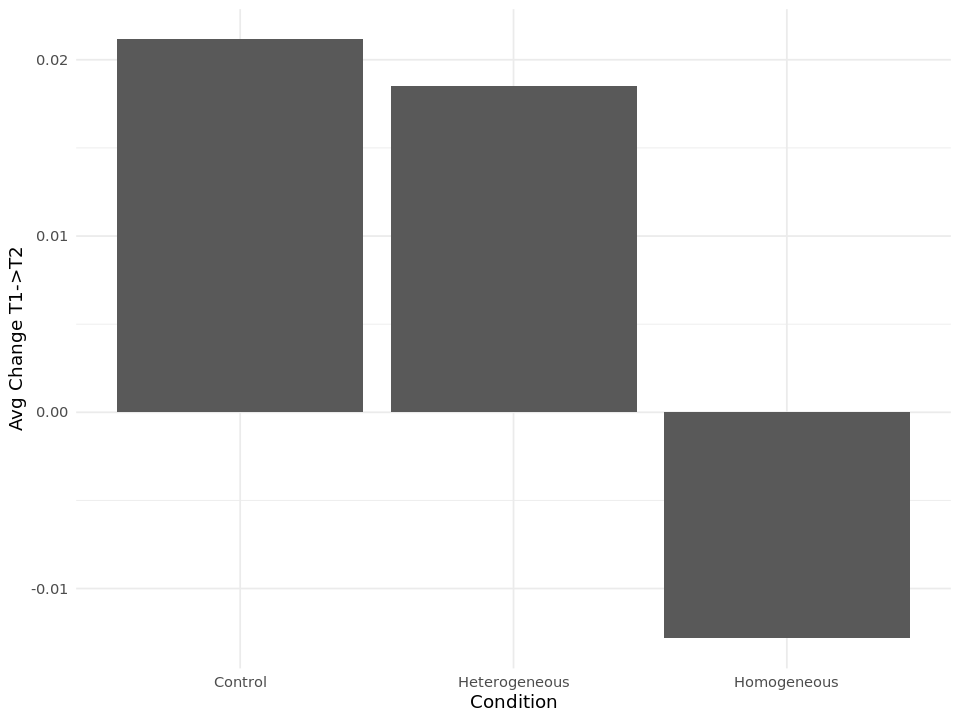

In [28]:
# Empirical Data 1 (T1-T1 change by condition)
# Plot 1: T1 to T2 change by condition
ggplot(emp, aes(x = condition, y = mean_change_t1_t2)) +
  geom_col() +
  theme_minimal() +
  labs(x = "Condition", y = "Avg Change T1->T2")

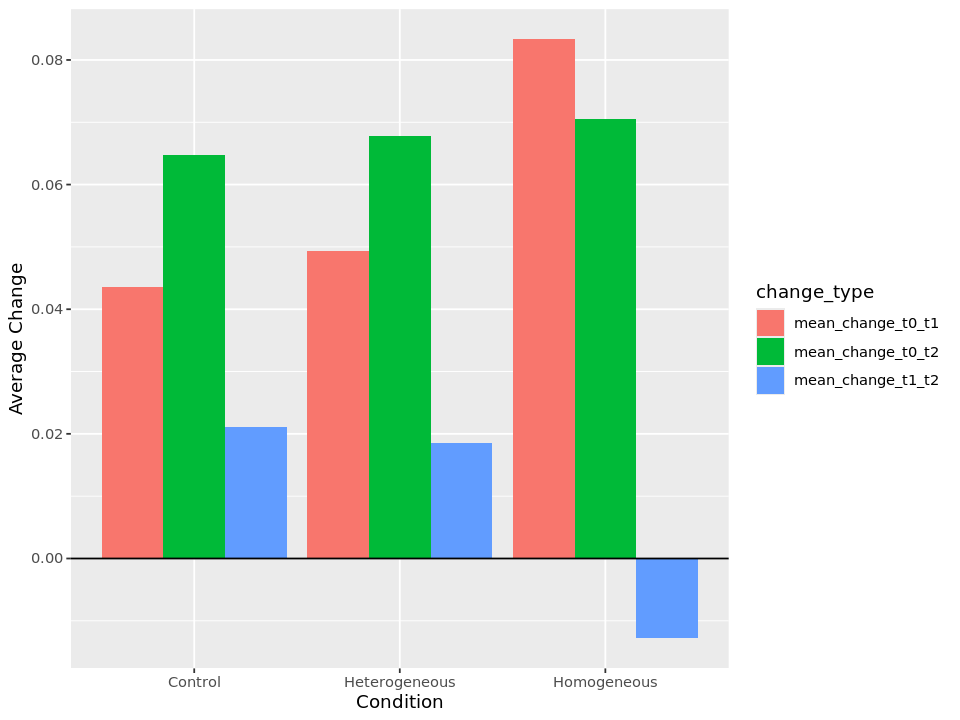

In [29]:
# Empirical Data 3 (Cross-time Comparison)
# Plot 2: Cross-time comparison
emp_long <- emp %>%
  tidyr::pivot_longer(
    cols = c(mean_change_t0_t1, mean_change_t1_t2, mean_change_t0_t2),
    names_to = "change_type",
    values_to = "value"
  )

ggplot(emp_long, aes(x = condition, y = value, fill = change_type)) +
  geom_col(position = "dodge") +
  geom_hline(yintercept = 0) +
  labs(x = "Condition", y = "Average Change")

In [4]:
# Empirical Data
## empirical bar chart for data change
## empirical_prep viz calls (bar chart for separate conditions and across them T0-T2)
### empirical_col & empirical_cross & empirical_cohen
cohen <- ga_outputs$results$comparisons$empirical_cohen
cat(sprintf("Pro-reduction effect (standardized β): %.3f\n", cohen$std_estimate))
cat(sprintf("Interpretation: %s effect size\n",
            ifelse(abs(cohen$std_estimate) < 0.2, "small",
            ifelse(abs(cohen$std_estimate) > 0.5, "small-to-medium", "medium-plus"))))

Pro-reduction effect (standardized β): -0.033
Interpretation: small effect size


## Empirical Data Interpretation
- Across all three experimental conditions the largest mean change came in the period T0-T1 with little change (in the order of 0.02 compared with 0.04-0.05 - on a scale of [0,1]) for the period of T1-T2.
- This could suggest that most of the attitude change that occurred in the empirical study was as a result of the information document before deliberation occurred at T2
- One further point of interest is taking into consideration the SD of the mean change from T0-T1 and T1-T2, in both cases one can clearly see that the standard deviation is sometimes up to x2 larger than the mean opinion change -> potentially suggesting that the noise surrounding the signal is larger than the signal itself

# Hypothesis 1a
What does it test: 
This hypothesis tests whether the attitudes of agents prior to deliberation (T1) are positively correlated to their attitudes after deliberation (T2) as a measure of the variance explained in the T2 opinion, accounting for the fact that an individual agent pertains to and only interacts with other agents in a specific debate group.

In [33]:
# Hypothesis 1 - model H1a
print(ga_outputs$results$models$mlm_h1a)
lapply(list(h1a = ga_outputs$results$models$mlm_h1a), broom.mixed::tidy, conf.int = TRUE)

Linear mixed model fit by REML ['lmerMod']
Formula: Attitude ~ Condition * Time + (1 | agent_id) + (1 | debate_label)
   Data: df_empir_long
REML criterion at convergence: -865.6903
Random effects:
 Groups       Name        Std.Dev.
 agent_id     (Intercept) 0.13132 
 debate_label (Intercept) 0.00000 
 Residual                 0.03657 
Number of obs: 418, groups:  agent_id, 209; debate_label, 43
Fixed Effects:
                (Intercept)         Conditionhomogeneous  
                    0.57716                     -0.12522  
                     TimeT2  Conditionhomogeneous:TimeT2  
                    0.02174                     -0.03833  
optimizer (nlminbwrap) convergence code: 0 (OK) ; 0 optimizer warnings; 1 lme4 warnings 


,effect,group,term,estimate,std.error,statistic,conf.low,conf.high
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,fixed,NA,(Intercept),0.57715785,0.011281829,51.158180,0.55504587,0.59926983
2,fixed,NA,Conditionhomogeneous,-0.12521782,0.020548607,-6.093737,-0.16549235,-0.08494329
3,fixed,NA,TimeT2,0.02174499,0.004280323,5.080222,0.01335571,0.03013427
4,fixed,NA,Conditionhomogeneous:TimeT2,-0.03833450,0.007796135,-4.917115,-0.05361464,-0.02305435
5,ran_pars,agent_id,sd__(Intercept),0.13132169,NA,NA,NA,NA
6,ran_pars,debate_label,sd__(Intercept),0.00000000,NA,NA,NA,NA
7,ran_pars,Residual,sd__Observation,0.03657109,NA,NA,NA,NA


For confidence bands, please install `qqplotr`.



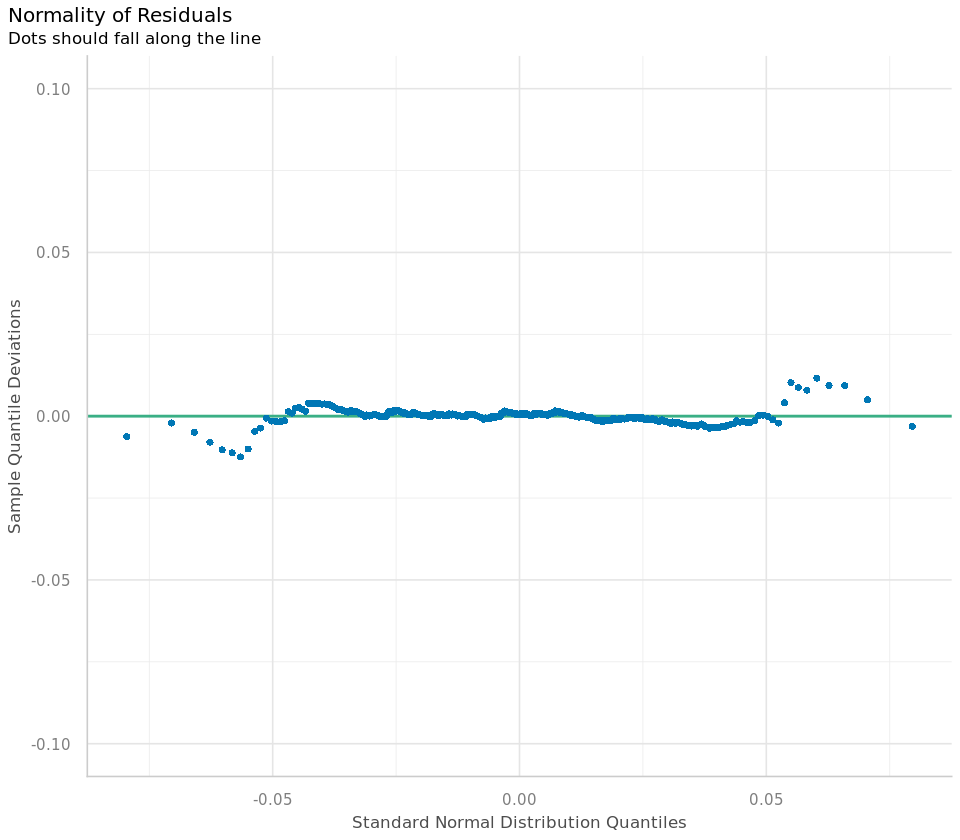

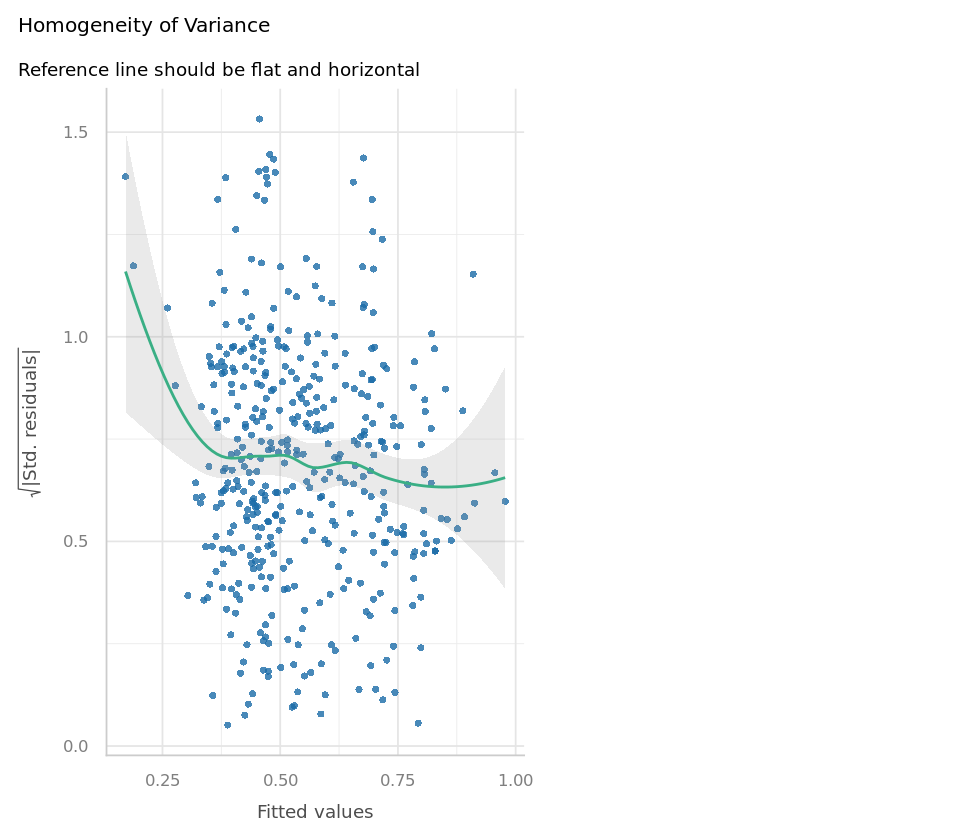

In [10]:
# Hypothesis 1 - model H1a Normality and Variance Viz
options(repr.plot.width = 8, repr.plot.heigh = 6)
plot(performance::check_normality(ga_outputs$results$models$mlm_h1a))
plot(performance::check_model(ga_outputs$results$models$mlm_h1a, check = "homogeneity"))

## Hypothesis H1a Interpretation
- The linear regression performed above followed a similar structure to the one set up by Dheilly et al. and to take into account the nested structure of the debates and the inviduals within them. Onne caveat is the fact that the multi-agent simulations were initialized with only the initial attitudes of participants and parameters were optimized across the entire set of debates implying that the regression performed here is simplified compared to what it could be in practice.
- 1) The main results being that heterogeneous debates have a positive movement across T1-T2 (0.022 or 2.2%) which is statistically significant
  2) Taken in context with the interaction term `Conditionhomogeneous:TimeT2` (-0.038) implies that homogeneous debates shifted in the negative direction from T1-T2
  3) Debate group context explains none of the attitude variance once individual differences are accounted for (debate_label SD = 0.0)
  4) Overall: hetero debates show a small positive shift and homogeneous a negative shift, both are dwarfed by the individual level SD (agent_id = 0.13) which is 6 times larger than the actual shift
- The normality of residuals plot illustrates that the data has some slight departures from normality at the tails which is to be expected with bounded data [0,1], implying that the data largely satisfies the assumption. 
- The homogeneity of variance is scattered but does not fan out or point to a funnel shape implying that the residual variance is quite large (consistent with agent_id SD = 0.13) but has not systematic pattern across the fitted values. The assumption of constant variance is approximately met.

# Hypothesis 1b
what does it test:
This hypothesis tests whether the empirical attitude with which agents are initialized in the agent-based models is positively correlated with the simulated attitude at the end of the debate, explaining a significant share of the variance. It follows the same nested structure whereby agents can only interact with other agents in a specific debate group.

In [7]:
# H1b table viz
lapply(ga_outputs$results$models$mlm_h1b, broom.mixed::tidy, conf.int = TRUE)

,effect,group,term,estimate,std.error,statistic,conf.low,conf.high
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,fixed,NA,(Intercept),0.5771578515,0.0107067247,53.9061076,0.5561730568,0.5981426463
2,fixed,NA,Conditionhomogeneous,-0.1252178163,0.0195011177,-6.4210584,-0.1634393046,-0.0869963280
3,fixed,NA,TimeT2,-0.0001782599,0.0002279905,-0.7818742,-0.0006251131,0.0002685933
4,fixed,NA,Conditionhomogeneous:TimeT2,0.0005002515,0.0004152596,1.2046719,-0.0003136423,0.0013141453
5,ran_pars,agent_id,sd__(Intercept),0.1293551801,NA,NA,NA,NA
6,ran_pars,debate_label,sd__(Intercept),0.0000000000,NA,NA,NA,NA
7,ran_pars,Residual,sd__Observation,0.0194795177,NA,NA,NA,NA
,effect,group,term,estimate,std.error,statistic,conf.low,conf.high
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


## Hypothesis 1b Interpretation
Commonalities between models:
- debate_label SD is zero and agent_id SD is non zero (ranging from 0.11-0.13) -> in terms of ICC (the proportion of variance explained by agent_id) {0.12^2 / (0.12^2 + 0.02^2)} ~ 0.97, meaning that individual differences explain approximately 97% of the variance
- heterogeneous debates have a slight negative change in attitude `TimeT2` estimate being very slightly negative
- homogeneous debataes have an approximately zero change in attitude across all models (consider `Conditionhomogeneous:TimeT2 + interaction term `TimeT2`), where only clustering is significant (t=2.21)
- main conclusion is that structural set up explains nothing, individual differences explain approximately 97% of the variance in attitude and the residual for each model (~ 0.02) implies that once we know who the agents are, we know their attitude within ±0.02.
- Key comparison: in H1a `TimeT2` was 0.022, here the simulated `TimeT2` is [-0.0002, -0.0005] -> the calibration algorithms found the path of least resistance and produce essentially no movement from T1-T2

# Hypothesis 2
what does it test:
(2) Individuals who are more likely to be receptive and influenced by social norms observed around them as well as those that are less likely to be able to exert control over their own actions are likely to change their attitude more in absolute terms before and after the debate, controlling for the strength of their attitude before the debate.

In [35]:
# Hypothesis 2 - model and regression
print(ga_outputs$results$models$mlm_h2_cent)
broom.mixed::tidy(ga_outputs$results$models$mlm_h2_cent, conf.int = TRUE)

Linear mixed model fit by REML ['lmerModLmerTest']
Formula: abs_change_t1_t2 ~ (perceived_norm_cent + self_control_cent) *  
    opinion_strength_cent + (1 | id_group_all)
   Data: df_empirical
REML criterion at convergence: -1634.323
Random effects:
 Groups       Name        Std.Dev. 
 id_group_all (Intercept) 2.365e-10
 Residual                 3.774e-02
Number of obs: 455, groups:  id_group_all, 242
Fixed Effects:
                              (Intercept)  
                                0.0440829  
                      perceived_norm_cent  
                                0.0010859  
                        self_control_cent  
                               -0.0001298  
                    opinion_strength_cent  
                               -0.0069718  
perceived_norm_cent:opinion_strength_cent  
                                0.0008316  
  self_control_cent:opinion_strength_cent  
                               -0.0006257  
optimizer (nloptwrap) convergence code: 0 (OK) ; 0 

,effect,group,term,estimate,std.error,statistic,df,p.value,conf.low,conf.high
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,fixed,NA,(Intercept),4.408287e-02,0.0018511747,23.8134546,449,1.189563e-81,0.0404448230,0.0477209077
2,fixed,NA,perceived_norm_cent,1.085871e-03,0.0007934058,1.3686206,449,1.718023e-01,-0.0004733783,0.0026451213
3,fixed,NA,self_control_cent,-1.298242e-04,0.0002572121,-0.5047359,449,6.139920e-01,-0.0006353131,0.0003756648
4,fixed,NA,opinion_strength_cent,-6.971832e-03,0.0192907418,-0.3614082,449,7.179643e-01,-0.0448831839,0.0309395194
5,fixed,NA,perceived_norm_cent:opinion_strength_cent,8.316254e-04,0.0068699114,0.1210533,449,9.037030e-01,-0.0126695468,0.0143327976
6,fixed,NA,self_control_cent:opinion_strength_cent,-6.257080e-04,0.0024990064,-0.2503827,449,8.024059e-01,-0.0055369090,0.0042854929
7,ran_pars,id_group_all,sd__(Intercept),2.364656e-10,NA,NA,NA,NA,NA,NA
8,ran_pars,Residual,sd__Observation,3.774005e-02,NA,NA,NA,NA,NA,NA


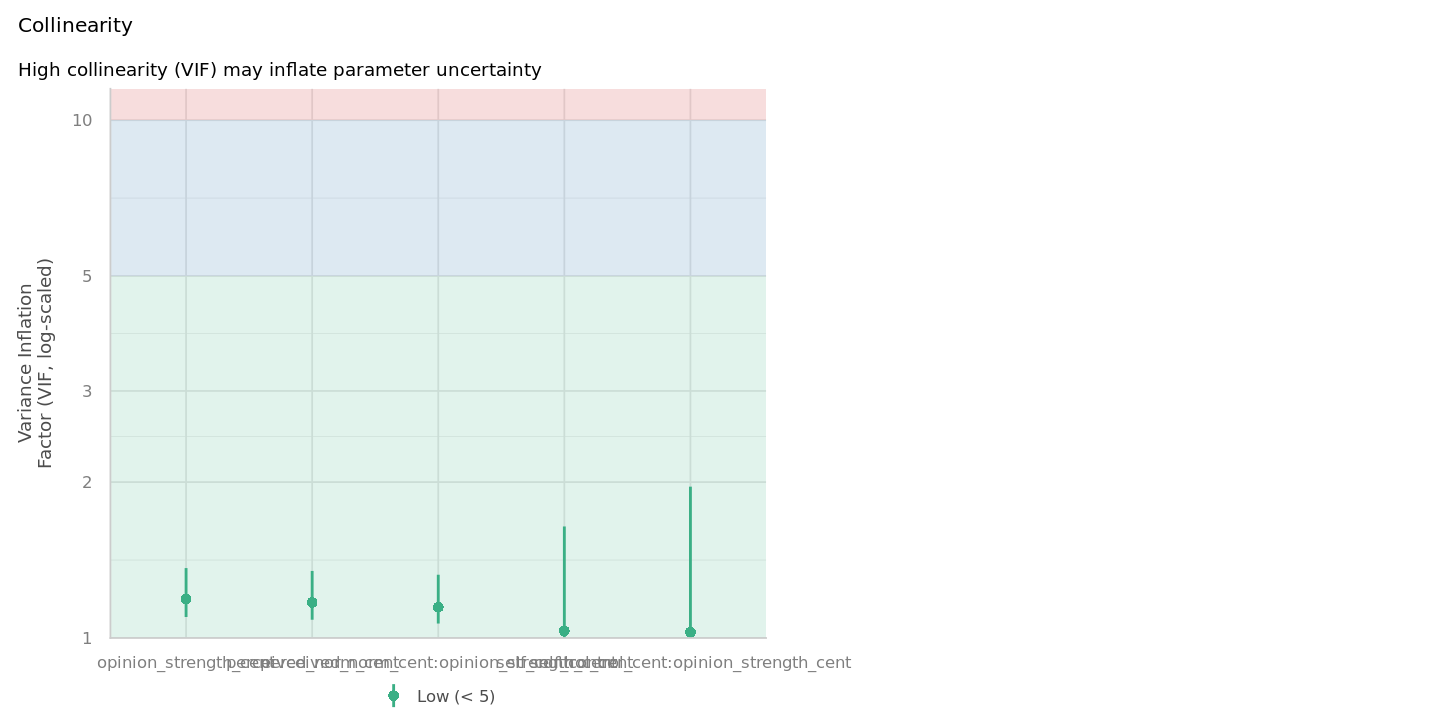

In [36]:
# Hypothesis 2 centered model (VIF has been corrected)
m <- ga_outputs$results$models$mlm_h2_cent
options(repr.plot.width = 12, repr.plot.height = 6)

# VIF
plot(performance::check_model(m, check = "vif"))

## Hypothesis 2 VIF Intepretation
The initial model conceived to test this hypothesis had significant issues with high collinearity of the interaction terms (VIF  > 50). Mean-centering `perceived_norms`, `self_control`, and `opinion_strength` before computing the interaction terms resolved this (VIF approximately 1) while preserving the individual-level variance and fixed-effect estimates.
- Mean-centering implies subtracting the mean from each variable

For confidence bands, please install `qqplotr`.



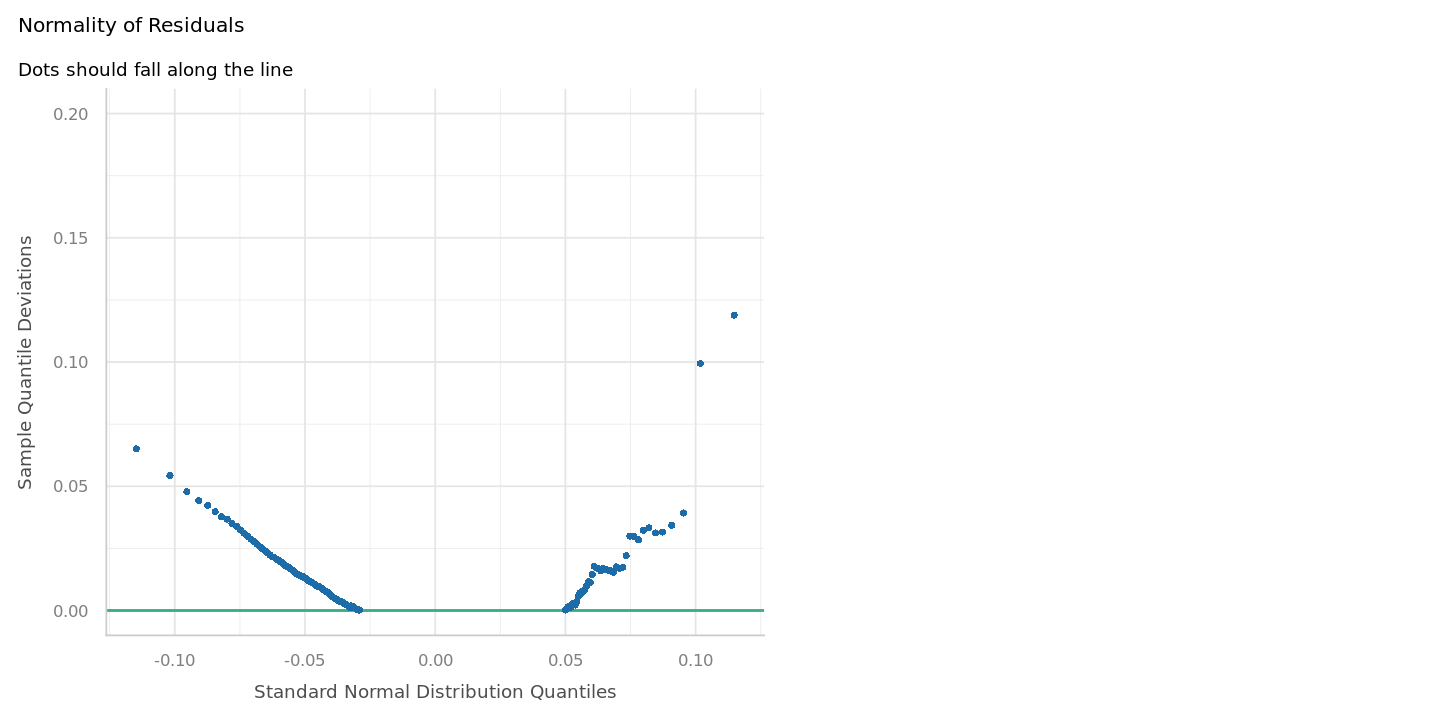

In [37]:
# H2 Centered QQ plot
options(repr.plot.width = 12, repr.plot.height = 6)
plot(performance::check_model(m, check = "qq"))

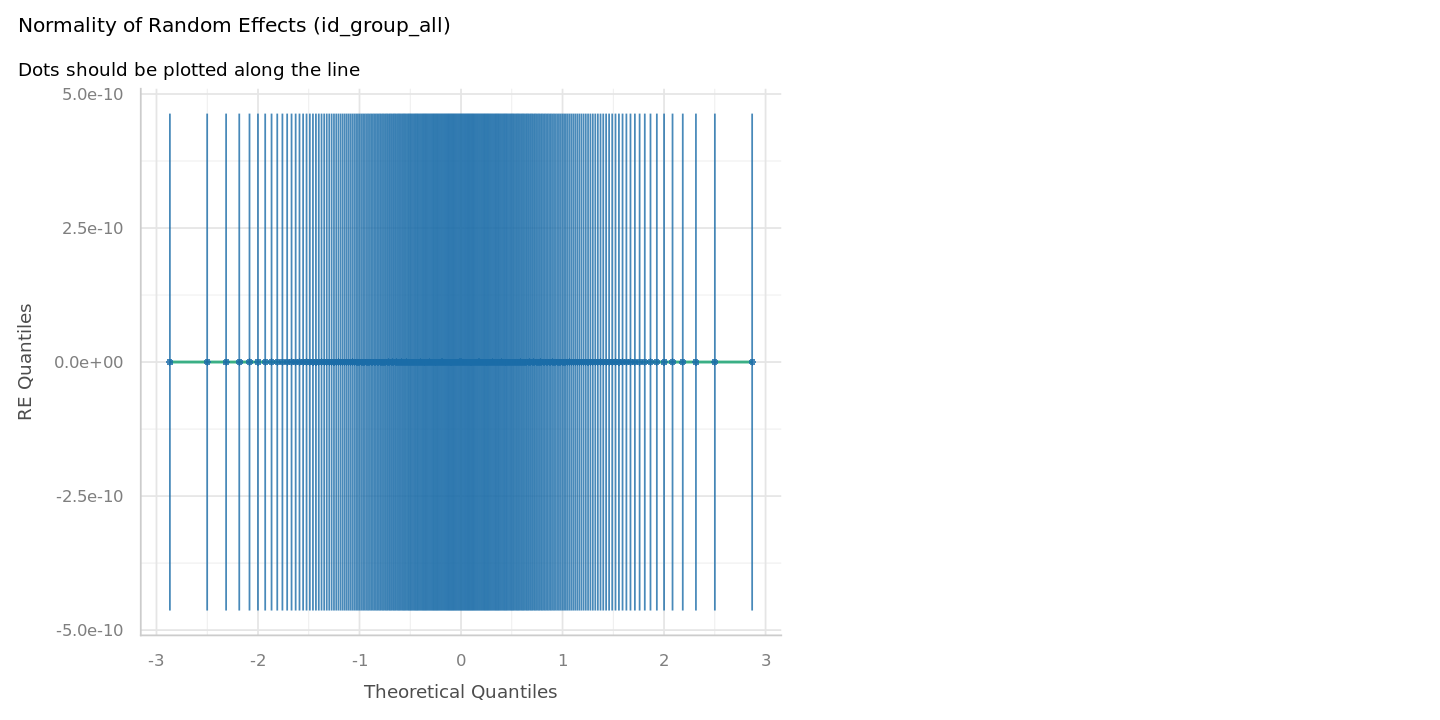

In [38]:
# H2 Centered reqq Plot
options(repr.plot.width = 12, repr.plot.height = 6)
plot(performance::check_model(m, check = "reqq"))

## Hypothesis 2 Interpretation
Regression:
- The regression above highlights the evident fact that none of the predictors reached significance (only `perceived_norm_cent` was marginally close, p = 0.118)
- Perceived norms, self-control and their interaction with opinion strength do not predict the absolute attitude change between T1-T2
- The debate group random intercept `id_group_all` estimates zero variance (2.4 x 10⁻¹⁰)
- This confirms the H1a finding that group assignment explains no variation in attitude change

Plots:
- QQ: clear departures from normality, the S shape indicates that the residual distribution has heavier tails than normal
- Normality of random effects: all random effect quantiles sit at zero
- Decision: H2 NOT SUPPORTED

# Hypothesis 3a
what does it test:
This hypothesis tests whether the agent-based simulations of social influence models better explain the real world behavior exhibited by agents compared with a model that assumes no change (or static agents) as well as a multilevel linear model that assumes the pre-deliberation attitudes are positively associated with post-deliberation attitudes for individual agents. The multilevel model is fitted on the calibration debates and evaluated on a held-out set.

In [41]:
# Hypothesis 3 - Benchmark
print(ga_outputs$results$models$mlm_bench_h3)
broom.mixed::tidy(ga_outputs$results$models$mlm_bench_h3, conf.int = TRUE)

Linear mixed model fit by REML ['lmerMod']
Formula: final_attitude ~ initial_opinion + (1 | debate_label)
   Data: df_ag_base
REML criterion at convergence: -622.0074
Random effects:
 Groups       Name        Std.Dev.
 debate_label (Intercept) 0.02477 
 Residual                 0.04884 
Number of obs: 209, groups:  debate_label, 43
Fixed Effects:
    (Intercept)  initial_opinion  
        0.03236          0.95904  


,effect,group,term,estimate,std.error,statistic,conf.low,conf.high
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,fixed,NA,(Intercept),0.03235768,0.01409987,2.294893,0.004722449,0.05999291
2,fixed,NA,initial_opinion,0.95904291,0.02439352,39.315486,0.911232503,1.00685333
3,ran_pars,debate_label,sd__(Intercept),0.02477066,NA,NA,NA,NA
4,ran_pars,Residual,sd__Observation,0.04884191,NA,NA,NA,NA


In [42]:
# Hypothesis 3a
broom.mixed::tidy(ga_outputs$results$models$mlm_h3a, conf.int = TRUE)

,effect,group,term,estimate,std.error,statistic,conf.low,conf.high
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,fixed,NA,(Intercept),4.585828e-02,0.006193080,7.404762032,0.03372007,0.05799650
2,fixed,NA,model_typebipolarization,-1.276692e-04,0.005663501,-0.022542462,-0.01122793,0.01097259
3,fixed,NA,model_typeclustering,-2.386413e-05,0.005663501,-0.004213672,-0.01112412,0.01107639
4,fixed,NA,model_typeconsensus,-2.515807e-04,0.005663501,-0.044421415,-0.01135184,0.01084868
5,ran_pars,debate_label,sd__(Intercept),1.630212e-02,NA,NA,NA,NA
6,ran_pars,Residual,sd__Observation,3.076068e-02,NA,NA,NA,NA


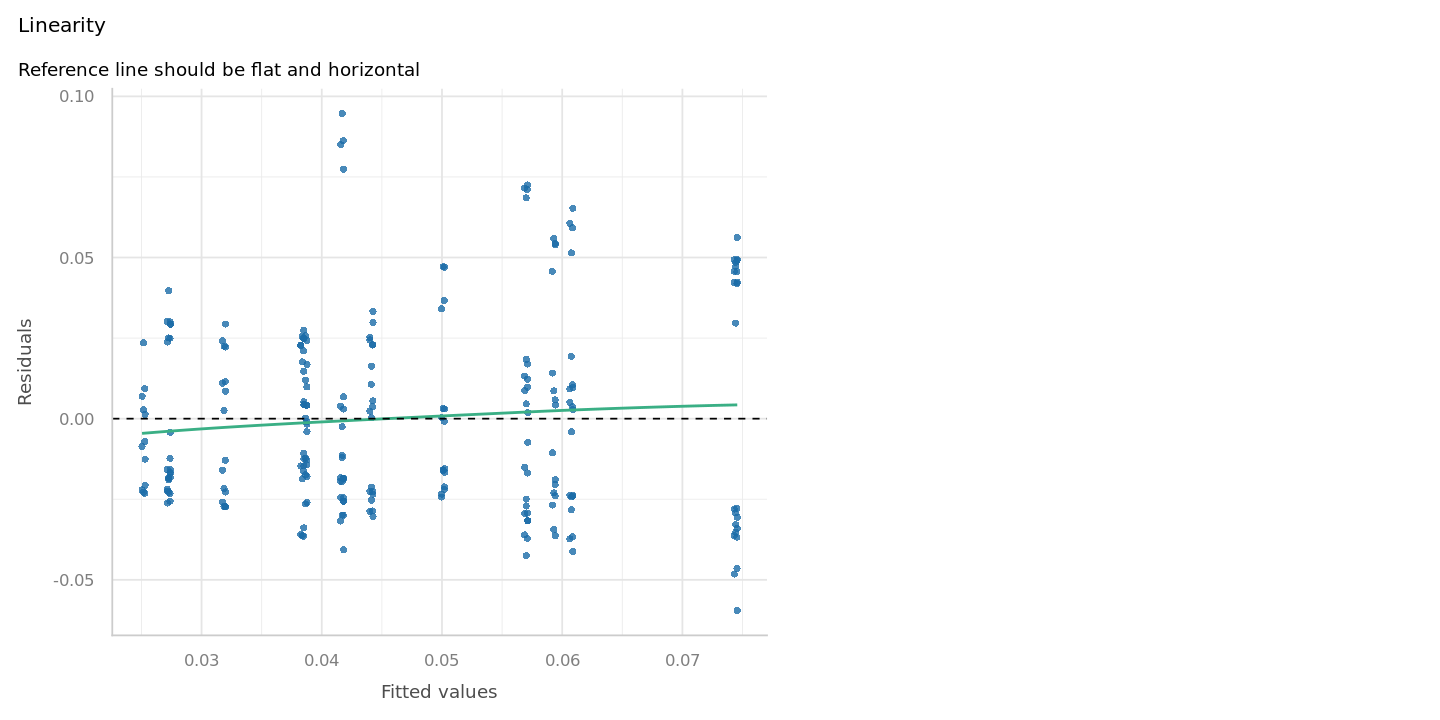

In [39]:
# Hypothesis 3a - Linearity of residuals vs fitted values
plot(check_model(ga_outputs$results$models$mlm_h3a, check = "linearity"))

For confidence bands, please install `qqplotr`.



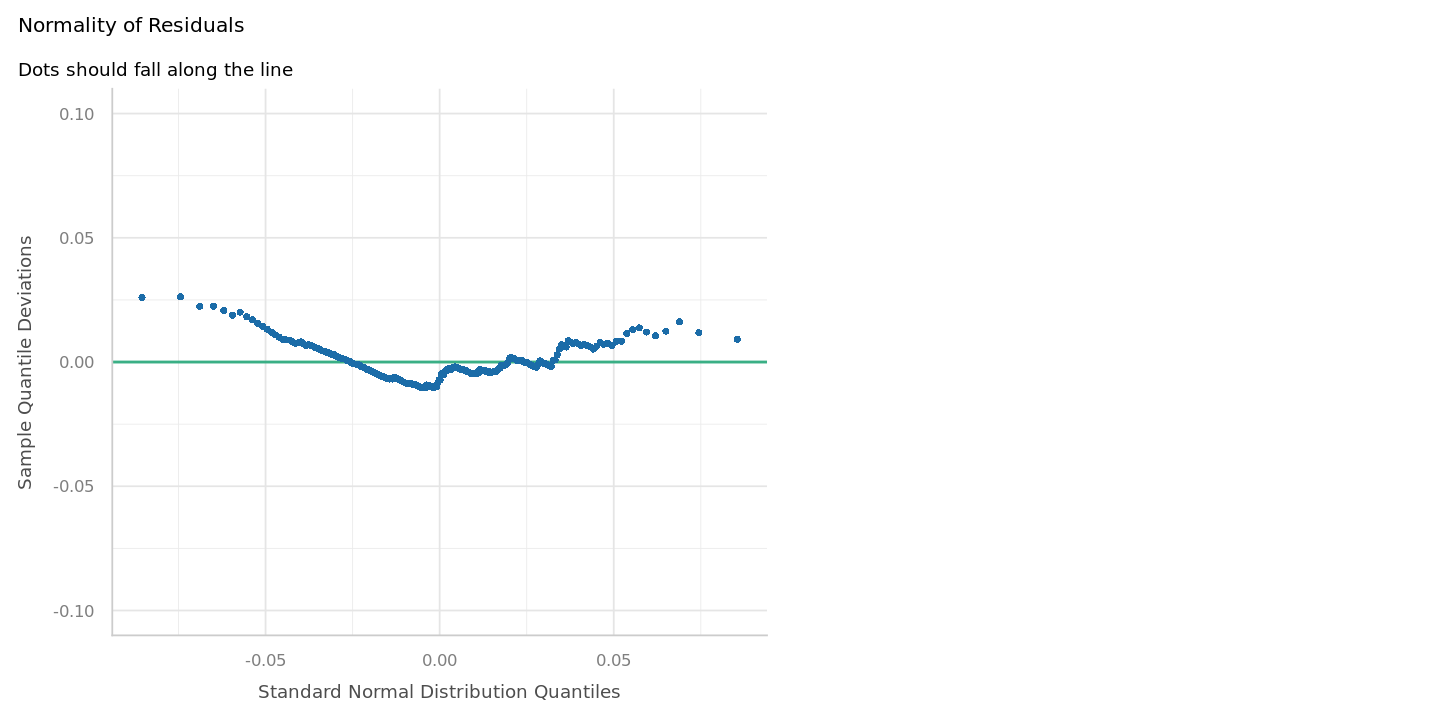

In [43]:
# Hypothesis 3a - Normality of Residuals
plot(check_model(ga_outputs$results$models$mlm_h3a, check = "qq"))

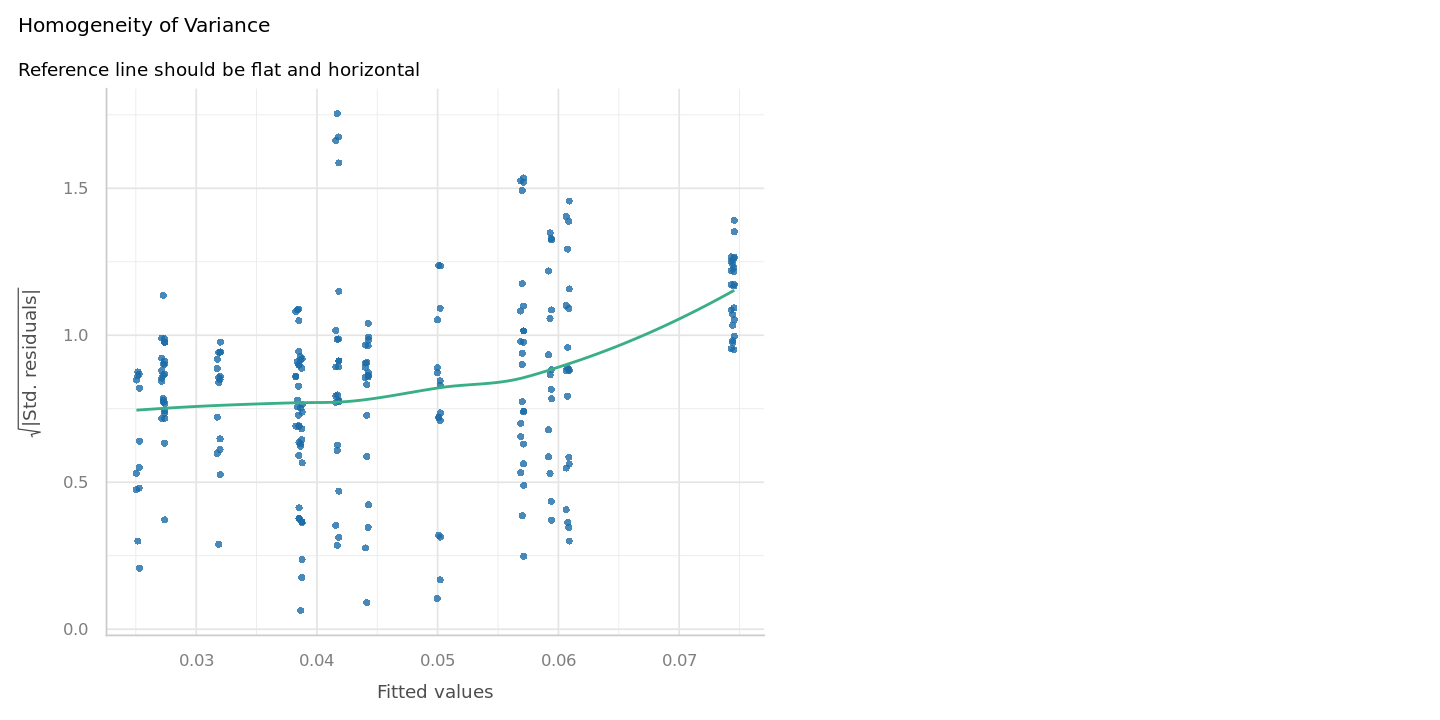

In [44]:
# Hypothesis 3a - Homogeneity of Variance
plot(check_model(ga_outputs$results$models$mlm_h3a, check = "homogeneity"))

## Hypothesis 3a Interpretation
Benchmark:
- Initial opinion almost perfectly predicts the final_attitude after deliberation (β = 0.959, 95% CI [0.911, 1.007])
- The model is equivalent to the `no_change` baseline with a slight shrinkage towards the mean
- Debate_label SD (0.02) in terms of ICC is {0.025^2 / (0.025^2 + 0.049^2)} = 0.21 -> 21% of variance explained by data structure
- Residual is twice as large as the debate label SD
- Overall: individual pre-deliberation attitudes almost perfectly explain the post-deliberation attitudes and debate_label picks up the remaining slack

H3a:
- Individual models are indistinguishable from `no_change` their contrast estimates are: -0.0001, -0.00002, and -0.0003, debate_label explains about the same amount of variance as the benchmark test
- No individual model reaches significance
- H3a not supported

Plots:
- Linearity: mild upward trend, implying mild non-linearity, still passes the assumption
- QQ: heavy tails but most of the points are centered around zero, broadly supports the assumption of normality of residuals
- Homogeneity: results are somewhat homogeneous and do not show a cone or fanning out across fitted values

# Hypothesis 3b
what does it test: 
H3b follows the same structure as H3a with the caveat that we now investigate how well the agent-based simulations explain behavior considering debate level MAE. The multilevel model is again fitted on calibration debates and evaluated on a held-out set.

In [18]:
# H3b
ga_outputs$results$comparisons$abm_vs_nc
ga_outputs$results$comparisons$abm_vs_mlm

design_cell,wins,n,mean_diff,p,model_type
<chr>,<int>,<int>,<dbl>,<dbl>,<chr>
bipolarization_dist_nospeak,6,12,1.102062e-03,1.0000000,bipolarization
bipolarization_dist_speak,6,12,-6.608346e-05,1.0000000,bipolarization
bipolarization_ndist_nospeak,6,12,1.595067e-04,1.0000000,bipolarization
bipolarization_ndist_speak,5,12,-2.080544e-04,0.7744141,bipolarization
clustering_dist_nospeak,6,12,5.775276e-06,1.0000000,clustering
clustering_dist_speak,3,12,1.811471e-03,0.1459961,clustering
clustering_ndist_nospeak,7,12,-1.014984e-03,0.7744141,clustering
clustering_ndist_speak,7,12,-1.222223e-04,0.7744141,clustering
consensus_dist_nospeak,6,12,-2.863629e-04,1.0000000,consensus


design_cell,wins,n,mean_diff,p,model_type
<chr>,<int>,<int>,<dbl>,<dbl>,<chr>
bipolarization_dist_nospeak,6,12,0.0003218233,1.0000000,bipolarization
bipolarization_dist_speak,4,12,-0.0008463220,0.3876953,bipolarization
bipolarization_ndist_nospeak,7,12,-0.0006207318,0.7744141,bipolarization
bipolarization_ndist_speak,8,12,-0.0009882929,0.3876953,bipolarization
clustering_dist_nospeak,5,12,-0.0007744632,0.7744141,clustering
clustering_dist_speak,5,12,0.0010312326,0.7744141,clustering
clustering_ndist_nospeak,6,12,-0.0017952229,1.0000000,clustering
clustering_ndist_speak,6,12,-0.0009024608,1.0000000,clustering
consensus_dist_nospeak,6,12,-0.0010666014,1.0000000,consensus


NULL

## Hypothesis 3b Interpretation
What does a sign test ask: does the ABM consistently win across debates compared with `no_change` and an mlm?

Significance of a sign test: In this scenario a model needs to win at least 10/12 times to be significant with an alpha value of 0.05. If the ABM and baseline were equal, we should see 10+ wins in only 5% of samples.

ABM vs NC:
- Overall the consensus models win more than the bipolarization and clustering (no model has a statistically significant win rate compared to `no_change`
- A majority of the models have a negative mean difference implying that the ABM has a lower MAE than `no_change`
- Fail to reject the null hypothesis -> we find no support for H3b

ABM vs MLM:
- The model with the most wins is bipolarization with non-distinct agents and a speaking mechanic (8 wins) but it still does not reach significance
- The other models perform rather poorly with most winning aroudn 50% of the time
- No model reaches significance implying that we fail to reject the null hypothesis that ABMs are different in performance with respect to the MLM

# Hypothesis 4a
what does it test:
Debates composed of agents who are pro and anti meat consumption reduction (compared with only anti reduction) are more likely to change their attitude on average with respect to their pre and post debate attitudes in empirical debates.

In [14]:
# Hypothesis 4a
print(ga_outputs$results$comparisons$wilcox_h_m)
print(ga_outputs$results$models$h4a_means)


	Wilcoxon rank sum test with continuity correction

data:  abs(change_t1_t2) by composition
W = 9694.5, p-value = 0.007991
alternative hypothesis: true location shift is not equal to 0

# A tibble: 2 × 2
  composition mean_abs_change
  <chr>                 <dbl>
1 H                    0.0522
2 M                    0.0399


## Hypothesis 4a Interpretation
Overall, the effect of H4a is significant with an alpha of 0.05 but in the opposite direction of the prediction. More specifically the mean change for homogeneous groups was greater than that of heterogeneous groups in the empirical data.

# Hypothesis 4b
what does it test:
This hypothesis tests whether the simulated models that consider heterogeneous debates change more on average when compared to homogeneous debate composition, i.e. producing the composition effect when initialized on empirical T1 attitudes. 

In [12]:
# Hypothesis 4b 
print(ga_outputs$results$models$df_h4b)

# A tibble: 8 × 5
  current_condition model_type     mean_abs_change     sd     n
  <chr>             <chr>                    <dbl>  <dbl> <int>
1 heterogeneous     bipolarization          0.0219 0.0213   146
2 heterogeneous     clustering              0.0131 0.0156   146
3 heterogeneous     consensus               0.0551 0.0378   146
4 heterogeneous     no_change               0      0        146
5 homogeneous       bipolarization          0.0250 0.0240    63
6 homogeneous       clustering              0.0125 0.0197    63
7 homogeneous       consensus               0.0319 0.0258    63
8 homogeneous       no_change               0      0         63


## Hypothesis 4b Interpretation
Bipolarization: Homogeneous set up showed more mean absolute change than heterogeneous (0.0250 > 0.0219)
Clustering: Nearly identical with the heterogeneous group showing more change (0.0131 > 0.0125)
Consensus: Heterogeneous debates showed more mean absolute change than homogeneous debates (0.0551 > 0.0319)

Comparing this with H4a shows that only the bipolarization model follows the empirical pattern. H4b is not consistently supported.

# Hypothesis 5
what does it test: 
This hypothesis tests whether pooling the predictions of agent-based simulations across all debates, initialized with the empirical pre-deliberation attitudes better explains the post-deliberation shift toward consumption reduction compared with a single regression model fitted across all debates.

In [11]:
# Hypothesis 5 Comparison
print(ga_outputs$results$models$df_h5, width = Inf)

# A tibble: 3 × 10
  model_type     abm_pooled_mae mlm_pooled_mae difference h5_supported     n
* <chr>                   <dbl>          <dbl>      <dbl> <lgl>        <int>
1 bipolarization         0.0464         0.0474   -0.00101 TRUE            59
2 clustering             0.0485         0.0474    0.00106 FALSE           59
3 consensus              0.0463         0.0474   -0.00113 TRUE            59
       se abm_ci_lo abm_ci_hi mlm_inside_ci
*   <dbl>     <dbl>     <dbl> <lgl>        
1 0.00447    0.0377    0.0552 TRUE         
2 0.00465    0.0394    0.0576 TRUE         
3 0.00448    0.0375    0.0551 TRUE         


## Hypothesis 5 Interpretation
For all three models the MLM mae falls within the ABM CI indicating there it is not possible to distinguish the ABM from the MLM. The difference between ABM and MLM are of the order of 0.001. H5 is thus not supported.

# RQ1 Exploratory Model Analyses